# Demostración computacional: expansión logística multiobjetivo

**Pregunta:** ¿dónde abrir hasta 2 bodegas nuevas para atender 100.000 pedidos/mes, minimizando a la vez el **costo mensual C** y el **tiempo promedio de entrega T**?

Este notebook es la versión corta (≈ 1 minuto) del flujo completo del repositorio:

| Paso | Script completo | Aquí |
|---|---|---|
| 1. Limpieza de datos | `src/limpieza.py` | ver dos errores reales y cómo se corrigieron |
| 2. Modelo MILP | `src/modelo.py` | resolver en vivo |
| 3. Frente de Pareto | `src/pareto.py` (≈ 5 min) | una restricción ε en vivo + el frente ya calculado |

Requiere haber corrido `python src/limpieza.py` y `python src/pareto.py` al menos una vez.

In [1]:
import sys, time
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
from modelo import cargar_tablas, resolver, validar_solucion

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
RAW, PARETO = RAIZ / "data" / "raw", RAIZ / "reports" / "pareto"

## 1. Los datos crudos traen errores que cambiarían la decisión

Dos ejemplos de los ~6.200 registros de rutas. Si un costo inválido se usara tal cual (o un nulo se tratara como 0), el optimizador vería una bodega artificialmente barata.

In [2]:
rpb = pd.read_csv(RAW / "07_rutas_puerto_bodega.csv")
rbz = pd.read_csv(RAW / "08_rutas_bodega_zona.csv")
display(rpb[(rpb.puerto_id == "P02") & (rpb.bodega_id == "B013")])   # costo NEGATIVO
display(rbz[(rbz.bodega_id == "B018") & (rbz.zona_id == "Z036")])     # 180 días para 8 km

pron = pd.read_csv(RAW / "03_pronostico_demanda.csv")
print(f"Demanda cruda de octubre: {pron[pron.mes == '2026-10'].pedidos_proyectados.sum():,.0f} "
      f"(debería ser 100.000; hay {pron[pron.mes == '2026-10'].pedidos_proyectados.isna().sum()} nulo)")

,puerto_id,bodega_id,distancia_vial_estimada_km,costo_abastecimiento_cop_pedido,tiempo_abastecimiento_dias
112,P02,B013,89.200,-120.000,0.770


,bodega_id,zona_id,distancia_vial_estimada_km,tiempo_entrega_dias,costo_distribucion_cop_pedido,transportista,confiabilidad_pct
1055,B018,Z036,8.000,180.000,"3,091.000",Operador C,0.954


Demanda cruda de octubre: 95,433 (debería ser 100.000; hay 1 nulo)


**Regla aplicada:** nunca reemplazar por cero. Se imputa con la mediana de las 5 rutas válidas más parecidas en distancia (el tiempo tiene correlación 0,996 con la distancia); si no hay al menos 3 comparables, la ruta se excluye. Cada cambio queda en la bitácora:

In [3]:
cambios = pd.read_csv(RAIZ / "reports" / "cambios_limpieza.csv")
display(cambios[cambios.clave.isin(["P02|B013", "B018|Z036", "2026-10|Z003"])]
        [["archivo", "clave", "campo", "valor_original", "valor_nuevo", "accion"]])
print(f"Total de cambios registrados: {len(cambios)}")

,archivo,clave,campo,valor_original,valor_nuevo,accion
13,03_pronostico_demanda.csv,2026-10|Z003,pedidos_proyectados,NaN,4567,imputado
30,07_rutas_puerto_bodega.csv,P02|B013,costo_abastecimiento_cop_pedido,-120,2395,imputado
46,08_rutas_bodega_zona.csv,B018|Z036,tiempo_entrega_dias,180,0.76,imputado


Total de cambios registrados: 50


## 2. El modelo: minimizar solo el costo

MILP con 96 bodegas (binarias), 5.760 rutas bodega→zona y 192 rutas puerto→bodega. Solver: HiGHS.

In [4]:
tablas = cargar_tablas()
t0 = time.time()
p1 = resolver(tablas, objetivo="costo")
print(f"Resuelto en {time.time() - t0:.1f} s")
print(f"Bodegas nuevas: {p1.abiertas}  ·  C = {p1.costo / 1e6:,.1f} M COP/mes  ·  T = {p1.tiempo:.3f} días")
validar_solucion(tablas, p1)          # recalcula C y T fuera del solver y verifica restricciones
display(p1.utilizacion)

Resuelto en 2.0 s
Bodegas nuevas: ['B012']  ·  C = 1,575.2 M COP/mes  ·  T = 1.334 días


,bodega_id,municipio,capacidad,pedidos,utilizacion
0,B001,Bogotá,55000,"42,731.000",0.777
1,B012,Medellín,60000,"57,269.000",0.954


## 3. ε-restricción: ¿y si exigimos T ≤ 1,1 días?

Mismo modelo, una restricción más: $\min C$ sujeto a $T \le \tau$.

In [5]:
t0 = time.time()
p2 = resolver(tablas, objetivo="costo", tau=1.1)
print(f"Resuelto en {time.time() - t0:.1f} s")
comp = pd.DataFrame({
    "bodegas nuevas": [" + ".join(p1.abiertas), " + ".join(p2.abiertas)],
    "costo (M COP)": [p1.costo / 1e6, p2.costo / 1e6],
    "tiempo (días)": [p1.tiempo, p2.tiempo],
}, index=["min C", "min C con T ≤ 1,1"])
display(comp)
print(f"Costo adicional: {(p2.costo - p1.costo) / 1e6:,.2f} M/mes  ·  "
      f"tiempo ahorrado: {p1.tiempo - p2.tiempo:.3f} días ({(p1.tiempo - p2.tiempo) / p1.tiempo:.0%})")

Resuelto en 2.2 s


,bodegas nuevas,costo (M COP),tiempo (días)
min C,B012,"1,575.211",1.334
"min C con T ≤ 1,1",B012 + B013,"1,575.502",1.091


Costo adicional: 0.29 M/mes  ·  tiempo ahorrado: 0.243 días (18%)


Abrir **B013 en Cali** cuesta casi lo mismo: su costo fijo se compensa con menos distribución y abastecimiento. ¿Quién gana?

In [6]:
def tiempo_por_ciudad(sol):
    a = sol.asignacion.merge(tablas.demanda[["zona_id", "ciudad"]])
    return (a.pedidos * a.tiempo_entrega_dias).groupby(a.ciudad).sum() / a.groupby("ciudad").pedidos.sum()

display(pd.DataFrame({"min C": tiempo_por_ciudad(p1), "T ≤ 1,1": tiempo_por_ciudad(p2)}))

,min C,"T ≤ 1,1"
ciudad,,
Barranquilla,2.861,2.861
Bogotá,0.773,0.773
Bucaramanga,2.015,2.015
Cali,2.208,0.774
Medellín,0.778,0.778
Pereira,1.592,1.605


## 4. El frente de Pareto completo

Repitiendo el paso 3 para muchos τ (más un refinamiento automático) se obtienen 9 soluciones eficientes. Lo calcula `src/pareto.py` (≈ 5 min); aquí se cargan sus resultados.

,punto,bodegas_nuevas,municipios,costo_mcop,tiempo_dias
0,P1,B012,Medellín,"1,575.211",1.334
1,P2,B012 + B013,Medellín + Cali,"1,575.502",1.091
2,P3,B012 + B013,Medellín + Cali,"1,576.205",1.089
3,P4,B012 + B013,Medellín + Cali,"1,577.546",1.088
4,P5,B012 + B015,Medellín + Cali,"1,625.750",1.084
5,P6,B012 + B015,Medellín + Cali,"1,626.121",1.083
6,P7,B012 + B015,Medellín + Cali,"1,626.958",1.082
7,P8,B010 + B015,Medellín + Cali,"1,712.977",1.082
8,P9,B010 + B015,Medellín + Cali,"1,722.867",1.081


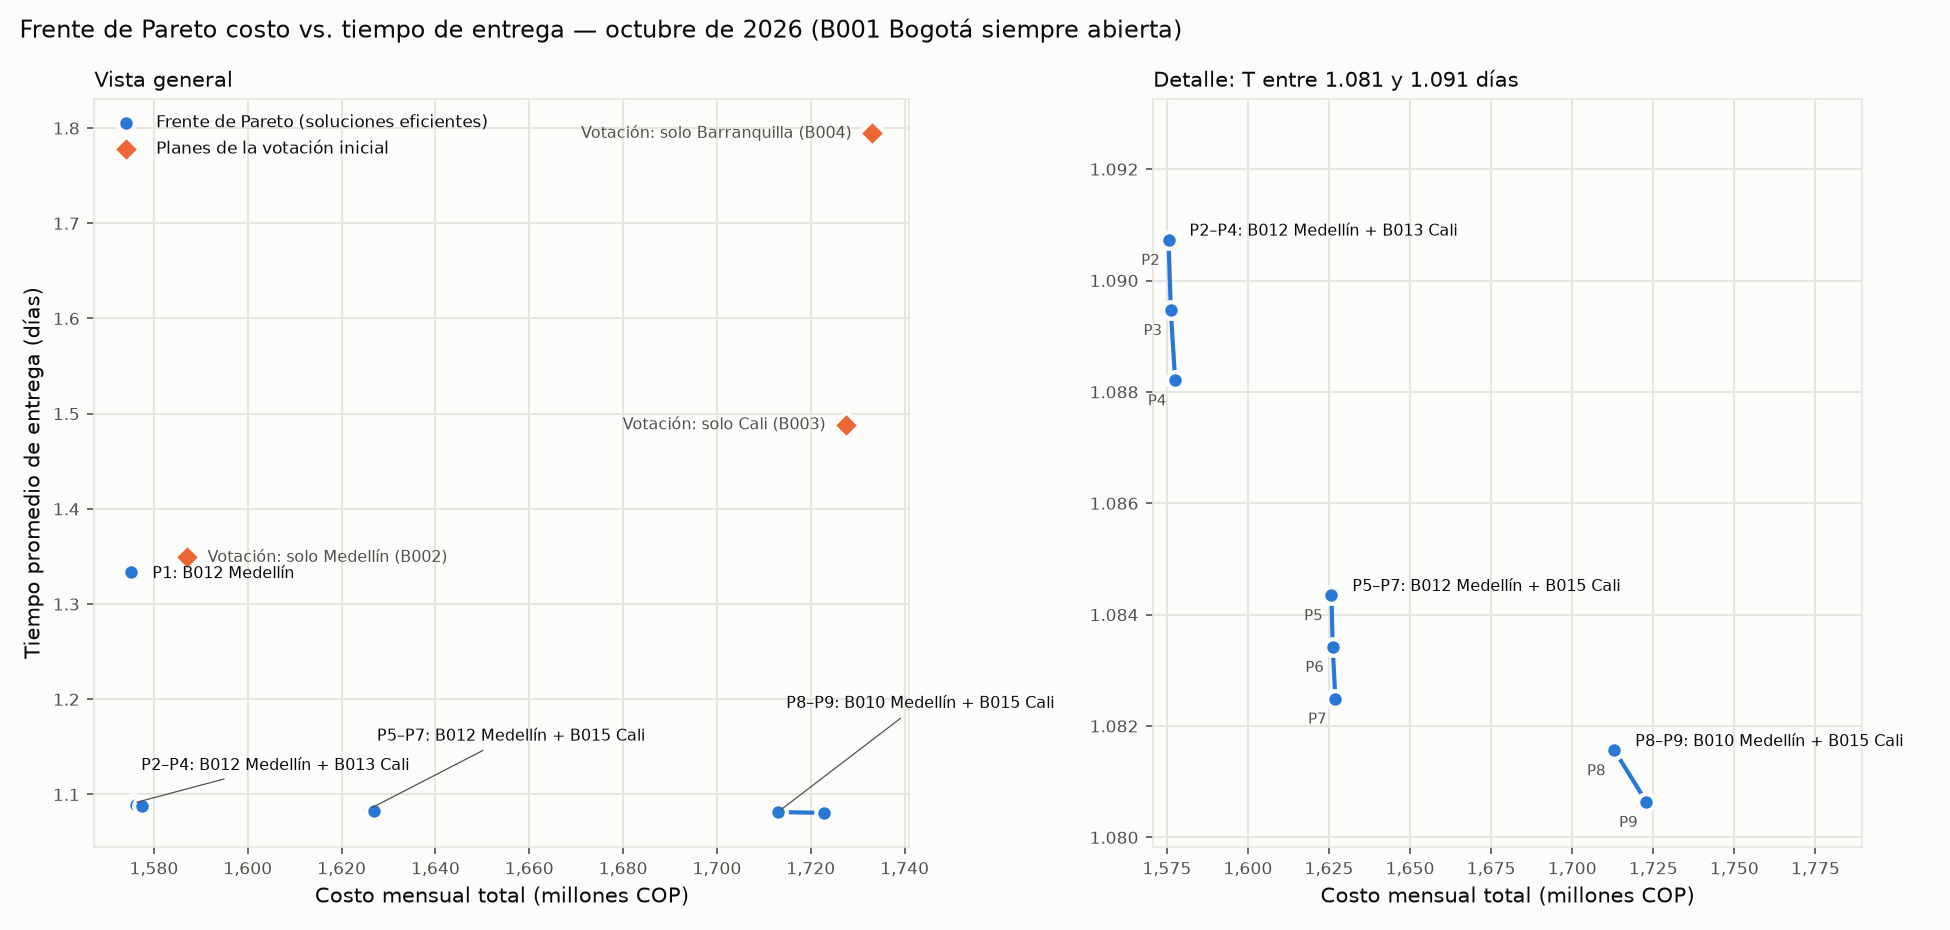

In [7]:
frente = pd.read_csv(PARETO / "puntos_eficientes.csv")
display(frente[["punto", "bodegas_nuevas", "municipios", "costo_mcop", "tiempo_dias"]])
display(Image(filename=PARETO / "frente_pareto.png"))

## 5. ¿Y la votación inicial?

In [8]:
voto = pd.read_csv(PARETO / "comparativo_votacion.csv")
display(voto[["plan", "bodega", "costo_mcop", "tiempo_dias", "eficiente", "sobrecosto_vs_mejor_dominante_mcop"]])

,plan,bodega,costo_mcop,tiempo_dias,eficiente,sobrecosto_vs_mejor_dominante_mcop
0,Votación: solo Medellín,B002,"1,586.980",1.349,False,11.769
1,Votación: solo Cali,B003,"1,727.562",1.488,False,152.351
2,Votación: solo Barranquilla,B004,"1,733.116",1.795,False,157.904


**Conclusión:** ninguna de las tres ciudades votadas es eficiente. El codo del frente es **B012 Medellín + B013 Cali**: +0,29 M COP/mes frente al mínimo costo, −18 % en tiempo promedio. Más allá, cada centésima de día cuesta decenas de millones.